<a href="https://colab.research.google.com/github/Nevin-Thomas/cos781-data-mining-group-project/blob/dev/Integrated_dataset_%2B_baseline_model%2Bclustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
%pip install gensim

In [11]:
%pip install ijson

In [12]:
# 1. IMPORTS
# =========================================================
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
import re, json, requests, random, nltk, gensim, torch, ijson
from concurrent import futures
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from transformers import AutoTokenizer, AutoModel
nltk.download('stopwords')
stop_words = nltk.corpus.stopwords.words('english')

print("✅ All core libraries loaded successfully")

✅ All core libraries loaded successfully


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [13]:
# 2. STREAM AMAZON REVIEWS DATA
# =========================================================
raw_urls = {
    'beauty': "https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023/resolve/main/raw/review_categories/All_Beauty.jsonl",
    'fashion': "https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023/resolve/main/raw/review_categories/Amazon_Fashion.jsonl",
}
meta_urls = {
    'beauty': "https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023/resolve/main/raw/meta_categories/meta_All_Beauty.jsonl",
    'fashion': "https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023/resolve/main/raw/meta_categories/meta_Amazon_Fashion.jsonl",
}

def stream_amazon_review_json_file(url, limit=10000):
    """Stream JSONL data efficiently from HuggingFace URLs"""
    rows = []
    try:
        res = requests.get(url, stream=True)
        res.raise_for_status()
        lines = (line.decode('utf-8') for line in res.iter_lines())
        for i, ln in enumerate(lines):
            if i > limit:
                break
            try:
                item = next(ijson.items(ln, '', multiple_values=True))
                rows.append(item)
            except Exception:
                continue
    except Exception as e:
        print(f"⚠️ Stream error: {e}")
    return rows

def load_all_datasets(url_dict, nrows=10000):
    """Concurrent loader for multiple JSON URLs"""
    all_data = []
    with futures.ThreadPoolExecutor() as executor:
        futs = [executor.submit(stream_amazon_review_json_file, url, nrows) for url in url_dict.values()]
        for future in futures.as_completed(futs):
            try:
                all_data.extend(future.result())
            except Exception as e:
                print(f"⚠️ Load failed: {e}")
    return all_data

reviews_raw = load_all_datasets(raw_urls, 10000)
meta_raw = load_all_datasets(meta_urls, 10000)

df_reviews = pd.DataFrame(reviews_raw)
df_meta = pd.DataFrame(meta_raw)

In [14]:
# 3. DATA CLEANING & MERGING
# =========================================================
df_reviews = df_reviews.drop(['images','asin','user_id','timestamp','helpful_vote'], axis=1, errors='ignore')
df_meta = df_meta.drop(['bought_together','subtitle','author','videos','images','store','rating_number','categories','details','price'], axis=1, errors='ignore')

df_reviews = df_reviews.rename(columns={'title':'product_review_title', 'text':'review'})
df_meta = df_meta.rename(columns={'title':'product_title'})

df = pd.merge(df_reviews, df_meta, on='parent_asin', how='inner')
df = df.dropna().astype(str).drop_duplicates()

print(f"✅ Combined dataset shape: {df.shape}")
print(df[['review','rating','product_title']].head())

✅ Combined dataset shape: (1336, 10)
                                              review rating  \
0  I just had to replace my old Fitbit 3 to the c...    5.0   
1  These are lovely... soft.. comfortable... I wo...    5.0   
2        Pretty colors and great deal for the price!    5.0   
3                     Love so cute on are little man    4.0   
4  a bit pricey for a single, and i agree the ad ...    3.0   

                                       product_title  
0  AVOD Nylon Watch Bands Compatible with Fitbit ...  
1  SIEFERSN Fashion Design Women's Lambskin Touch...  
2  Kalon 6 Pack Women's Hipster Brief Nylon Spand...  
3  Toddler Boy Clothes Camo Ain T No Nana Like Th...  
4  Sarah's Silks Playsilk - 100% Real Silk, Hand ...  


In [15]:
# 4. TEXT CLEANING & LABEL CREATION
# =========================================================
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = [w for w in text.split() if w not in stop_words]
    return " ".join(tokens)

df["clean_text"] = df["review"].apply(clean_text)

# Label sentiment based on rating
df["label"] = df["rating"].astype(float).apply(lambda x: "positive" if x >= 4 else ("negative" if x <= 2 else "neutral"))
df = df[df["label"] != "neutral"]  # drop neutrals for binary sentiment

X = df["clean_text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

# =========================================================
# 5. EVALUATION FUNCTION
# =========================================================
def evaluate(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, pos_label="positive")
    rec = recall_score(y_true, y_pred, pos_label="positive")
    f1 = f1_score(y_true, y_pred, pos_label="positive")
    print(f"\n📊 {name} RESULTS:")
    print(classification_report(y_true, y_pred))
    return [name, acc, prec, rec, f1]

results = []

In [16]:
# =========================================================
# 6. BASELINE MODELS
# =========================================================

## (a) BoW + Naive Bayes
bow = CountVectorizer(max_features=2000)
X_train_bow = bow.fit_transform(X_train)
X_test_bow = bow.transform(X_test)
nb = MultinomialNB()
nb.fit(X_train_bow, y_train)
pred_bow = nb.predict(X_test_bow)
results.append(evaluate("BoW + Naive Bayes", y_test, pred_bow))

## (b) TF-IDF + Logistic Regression
tfidf = TfidfVectorizer(max_features=2000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)
lr = LogisticRegression(max_iter=500)
lr.fit(X_train_tfidf, y_train)
pred_tfidf = lr.predict(X_test_tfidf)
results.append(evaluate("TF-IDF + Logistic Regression", y_test, pred_tfidf))

## (c) Word2Vec + Random Forest
sentences = [t.split() for t in X_train]
w2v = gensim.models.Word2Vec(sentences, vector_size=100, window=5, min_count=1, workers=4)
def embed_w2v(text):
    words = [w for w in text.split() if w in w2v.wv]
    return np.mean([w2v.wv[w] for w in words], axis=0) if len(words) > 0 else np.zeros(100)
X_train_w2v = np.vstack([embed_w2v(t) for t in X_train])
X_test_w2v = np.vstack([embed_w2v(t) for t in X_test])
rf_w2v = RandomForestClassifier(n_estimators=100, random_state=42)
rf_w2v.fit(X_train_w2v, y_train)
pred_w2v = rf_w2v.predict(X_test_w2v)
results.append(evaluate("Word2Vec + Random Forest", y_test, pred_w2v))

## (d) GloVe + Random Forest

import os, zipfile, requests

# Step 1: Download GloVe if not already downloaded
glove_dir = "glove"
os.makedirs(glove_dir, exist_ok=True)
glove_path = os.path.join(glove_dir, "glove.6B.100d.txt")

if not os.path.exists(glove_path):
    print("⬇️ Downloading GloVe embeddings (100d)...")
    url = "http://nlp.stanford.edu/data/glove.6B.zip"
    r = requests.get(url)
    with open(os.path.join(glove_dir, "glove.6B.zip"), "wb") as f:
        f.write(r.content)
    with zipfile.ZipFile(os.path.join(glove_dir, "glove.6B.zip"), "r") as zip_ref:
        zip_ref.extractall(glove_dir)
    print("✅ GloVe downloaded and extracted.")

# Step 2: Load GloVe vectors into a dictionary
print("🔄 Loading GloVe embeddings into memory...")
glove_embeddings = {}
with open(glove_path, 'r', encoding='utf8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype='float32')
        glove_embeddings[word] = vector
print(f"✅ Loaded {len(glove_embeddings):,} word vectors from GloVe.")

# Step 3: Function to embed reviews using GloVe
def embed_glove(text):
    words = [w for w in text.split() if w in glove_embeddings]
    if len(words) == 0:
        return np.zeros(100)
    return np.mean([glove_embeddings[w] for w in words], axis=0)

# Step 4: Generate GloVe embeddings for train/test
X_train_glove = np.vstack([embed_glove(t) for t in X_train])
X_test_glove = np.vstack([embed_glove(t) for t in X_test])

# Step 5: Train and evaluate a classifier
rf_glove = RandomForestClassifier(n_estimators=100, random_state=42)
rf_glove.fit(X_train_glove, y_train)
pred_glove = rf_glove.predict(X_test_glove)

results.append(evaluate("GloVe + Random Forest", y_test, pred_glove))


## (e) BERT + Random Forest (fastest transformer test)
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
bert_model = AutoModel.from_pretrained("bert-base-uncased")

def embed_bert(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=64)
    with torch.no_grad():
        outputs = bert_model(**inputs)
    return outputs.last_hidden_state[:,0,:].numpy().flatten()

X_train_bert = np.vstack([embed_bert(t) for t in X_train])  # Use ALL training data
X_test_bert = np.vstack([embed_bert(t) for t in X_test])    # Use ALL test data
rf_bert = RandomForestClassifier(n_estimators=100, random_state=42)
rf_bert.fit(X_train_bert, y_train)  # Remove .sample(200)
pred_bert = rf_bert.predict(X_test_bert)
results.append(evaluate("BERT + Random Forest", y_test, pred_bert))


📊 BoW + Naive Bayes RESULTS:
              precision    recall  f1-score   support

    negative       0.62      0.30      0.40        44
    positive       0.89      0.97      0.93       257

    accuracy                           0.87       301
   macro avg       0.75      0.63      0.66       301
weighted avg       0.85      0.87      0.85       301


📊 TF-IDF + Logistic Regression RESULTS:
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00        44
    positive       0.85      1.00      0.92       257

    accuracy                           0.85       301
   macro avg       0.43      0.50      0.46       301
weighted avg       0.73      0.85      0.79       301



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



📊 Word2Vec + Random Forest RESULTS:
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00        44
    positive       0.85      1.00      0.92       257

    accuracy                           0.85       301
   macro avg       0.43      0.50      0.46       301
weighted avg       0.73      0.85      0.78       301

🔄 Loading GloVe embeddings into memory...
✅ Loaded 400,000 word vectors from GloVe.

📊 GloVe + Random Forest RESULTS:
              precision    recall  f1-score   support

    negative       0.67      0.09      0.16        44
    positive       0.86      0.99      0.92       257

    accuracy                           0.86       301
   macro avg       0.77      0.54      0.54       301
weighted avg       0.84      0.86      0.81       301


📊 BERT + Random Forest RESULTS:
              precision    recall  f1-score   support

    negative       0.33      0.02      0.04        44
    positive       0.86      0.99      0.92      


=== MODEL COMPARISON ===
                          Model  Accuracy  Precision    Recall        F1
0             BoW + Naive Bayes  0.870432   0.889286  0.968872  0.927374
1  TF-IDF + Logistic Regression  0.853821   0.853821  1.000000  0.921147
2      Word2Vec + Random Forest  0.850498   0.853333  0.996109  0.919210
3         GloVe + Random Forest  0.860465   0.864407  0.992218  0.923913
4          BERT + Random Forest  0.850498   0.855705  0.992218  0.918919


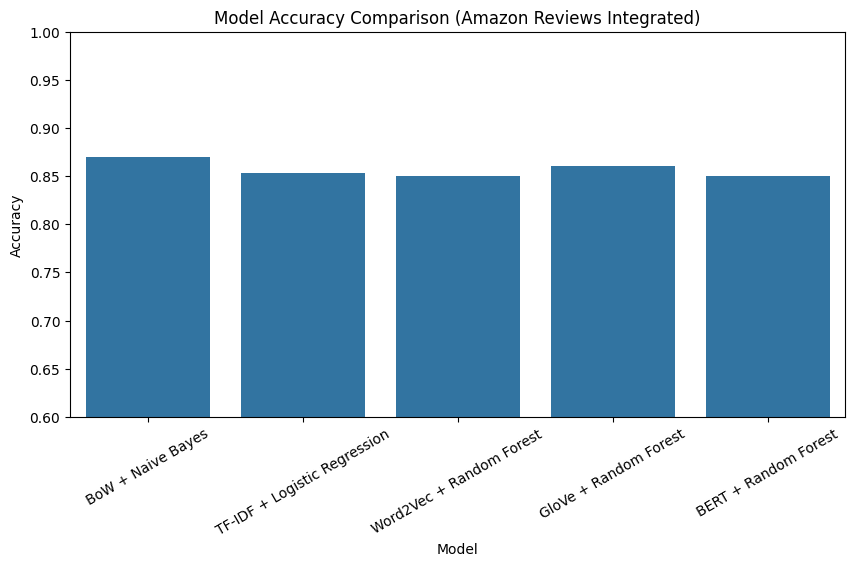

In [17]:
# 7. COMPARISON RESULTS
# =========================================================
df_results = pd.DataFrame(results, columns=["Model","Accuracy","Precision","Recall","F1"])
print("\n=== MODEL COMPARISON ===")
print(df_results)

plt.figure(figsize=(10,5))
sns.barplot(x="Model", y="Accuracy", data=df_results)
plt.title("Model Accuracy Comparison (Amazon Reviews Integrated)")
plt.xticks(rotation=30)
plt.ylim(0.6,1.0)
plt.show()

✅ K-Means done. Silhouette score: 0.465


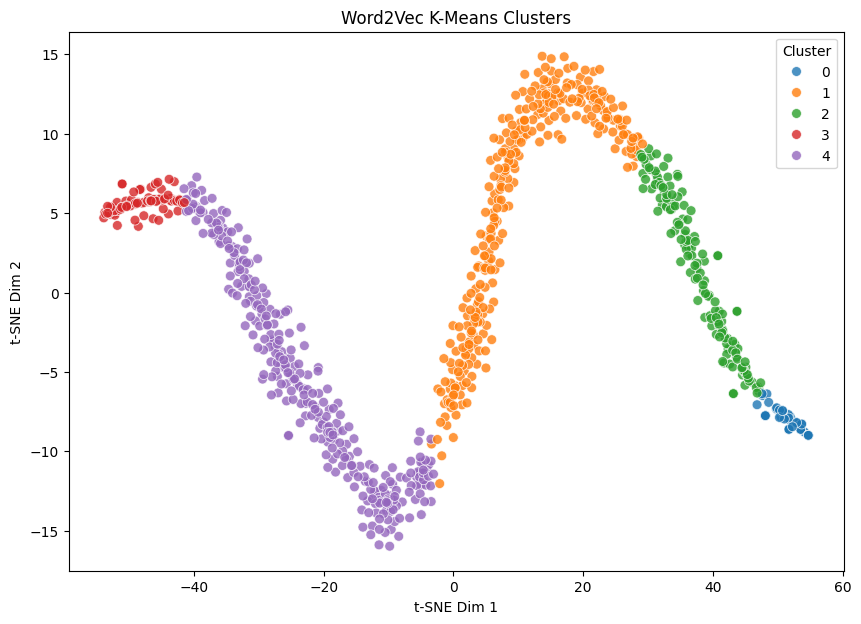

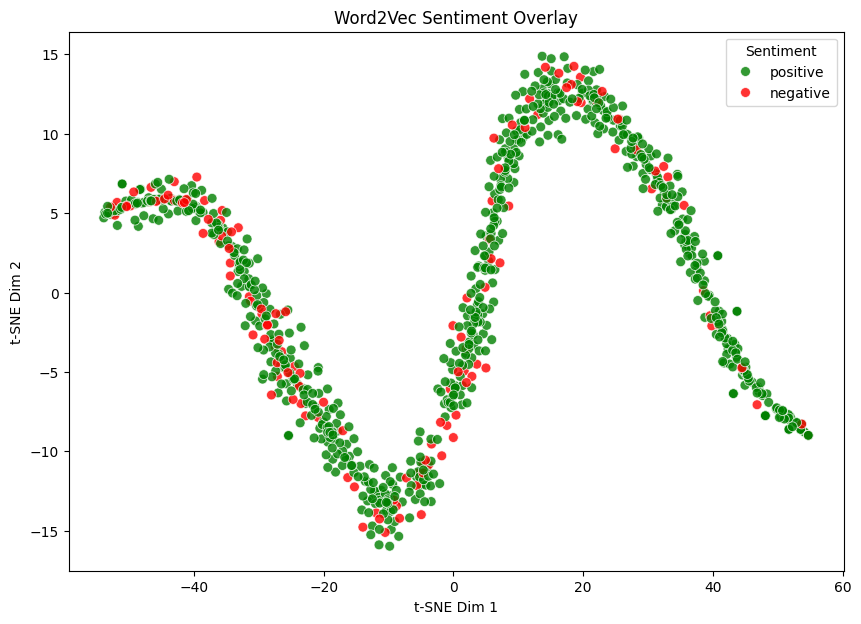

✅ Hierarchical clustering done (Ward linkage).


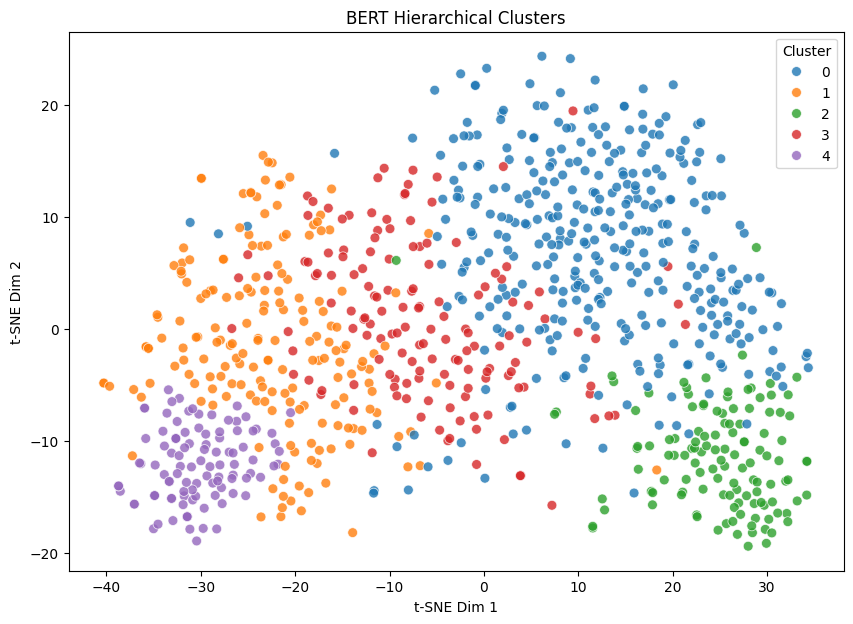

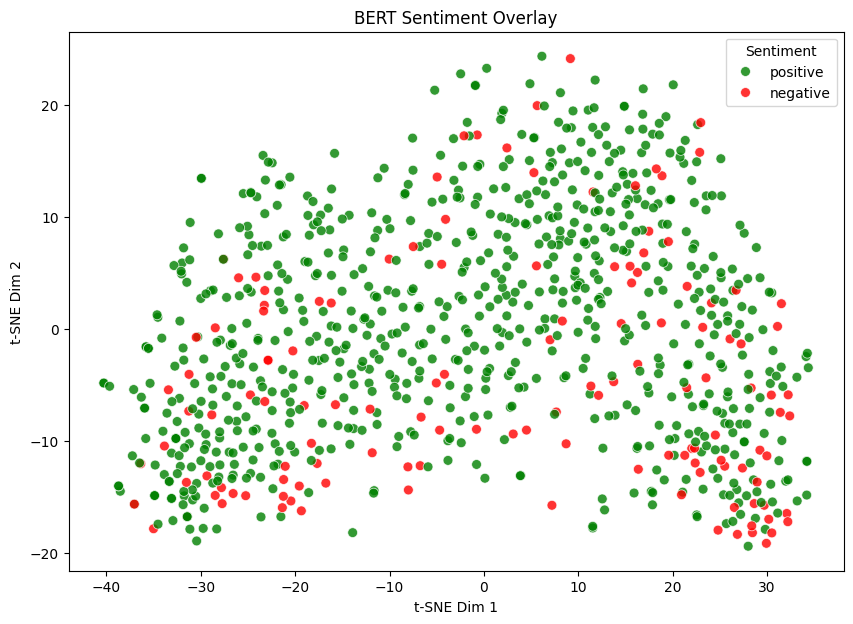

In [19]:
# =========================================================
# 8. CLUSTERING MODULE FOR AMAZON REVIEW EMBEDDINGS
# =========================================================
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score # Import silhouette_score
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# 8.1 Cluster embeddings
# -----------------------------
def cluster_embeddings(embeddings, method="hierarchical", n_clusters=5):
    """
    Cluster embeddings and return cluster labels.
    method: 'kmeans', 'hierarchical', 'graph'
    """
    if method == "hierarchical":
        # Filter zero vectors
        nonzero_idx = ~np.all(embeddings == 0, axis=1)
        labels = np.zeros(len(embeddings), dtype=int)
        if np.any(nonzero_idx):
            embeddings_filtered = embeddings[nonzero_idx]
            hier = AgglomerativeClustering(n_clusters=n_clusters, metric='euclidean', linkage='ward')
            labels_filtered = hier.fit_predict(embeddings_filtered)
            labels[nonzero_idx] = labels_filtered
        print("✅ Hierarchical clustering done (Ward linkage).")
        return labels

    elif method == "kmeans":
        kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
        labels = kmeans.fit_predict(embeddings)
        print(f"✅ K-Means done. Silhouette score: {silhouette_score(embeddings, labels):.3f}")
        return labels

    elif method == "graph":
        sim_matrix = cosine_similarity(embeddings)
        G = nx.Graph()
        for i in range(len(sim_matrix)):
            for j in range(i+1, len(sim_matrix)):
                if sim_matrix[i,j] > 0.8:  # similarity threshold
                    G.add_edge(i,j,weight=sim_matrix[i,j])

        labels = np.zeros(len(embeddings), dtype=int)  # default cluster 0 for isolated nodes
        try:
            import community as community_louvain
            if len(G.edges) > 0:
                partition = community_louvain.best_partition(G)
                for node, cluster_id in partition.items():
                    labels[node] = cluster_id
        except ImportError:
            print("⚠️ 'python-louvain' not installed. Using connected components instead.")
            for i, comp in enumerate(nx.connected_components(G)):
                for node in comp:
                    labels[node] = i

        print("✅ Graph-based clustering done.")
        return labels
    else:
        raise ValueError("Method must be 'kmeans', 'hierarchical', or 'graph'.")


# -----------------------------
# 8.2 Cluster + train classifier
# -----------------------------
def cluster_and_train(X_train_emb, X_test_emb, y_train, y_test, method="kmeans", n_clusters=5, classifier=None):
    # Cluster embeddings
    train_clusters = cluster_embeddings(X_train_emb, method, n_clusters)
    test_clusters = cluster_embeddings(X_test_emb, method, n_clusters)

    # LabelEncoder to handle unseen cluster IDs in test
    all_clusters = np.concatenate([train_clusters, test_clusters])
    le = LabelEncoder()
    le.fit(all_clusters)
    train_clusters_enc = le.transform(train_clusters)
    test_clusters_enc = le.transform(test_clusters)

    # Add cluster label as feature
    X_train_new = np.hstack([X_train_emb, train_clusters_enc.reshape(-1,1)])
    X_test_new = np.hstack([X_test_emb, test_clusters_enc.reshape(-1,1)])

    # Train classifier
    clf = classifier if classifier else RandomForestClassifier(n_estimators=100, random_state=42)
    clf.fit(X_train_new, y_train)
    y_pred = clf.predict(X_test_new)

    return evaluate(f"{method.capitalize()} + Classifier", y_test, y_pred)


# -----------------------------
# 8.3 2D t-SNE visualization
# -----------------------------
def visualize_clusters(embeddings, labels, title="Cluster Visualization", perplexity=30, random_state=42):
    tsne = TSNE(n_components=2, perplexity=perplexity, random_state=random_state, init='pca', learning_rate='auto')
    X_2d = tsne.fit_transform(embeddings)

    plt.figure(figsize=(10, 7))
    sns.scatterplot(x=X_2d[:,0], y=X_2d[:,1], hue=labels, palette="tab10", s=50, alpha=0.8)
    plt.title(title)
    plt.xlabel("t-SNE Dim 1")
    plt.ylabel("t-SNE Dim 2")
    plt.legend(title="Cluster", loc='best')
    plt.show()


# -----------------------------
# 8.4 Sentiment overlay visualization
# -----------------------------
def visualize_sentiment_overlay(embeddings, sentiment_labels, title="Sentiment Overlay", perplexity=30, random_state=42):
    tsne = TSNE(n_components=2, perplexity=perplexity, random_state=random_state, init='pca', learning_rate='auto')
    X_2d = tsne.fit_transform(embeddings)

    plt.figure(figsize=(10, 7))
    sns.scatterplot(
        x=X_2d[:,0], y=X_2d[:,1],
        hue=sentiment_labels,
        palette={"positive":"green", "negative":"red"},
        s=50, alpha=0.8
    )
    plt.title(title)
    plt.xlabel("t-SNE Dim 1")
    plt.ylabel("t-SNE Dim 2")
    plt.legend(title="Sentiment", loc='best')
    plt.show()


# -----------------------------
# 8.5 Apply to Amazon embeddings
# -----------------------------

# --- Word2Vec embeddings ---
w2v_labels_kmeans = cluster_embeddings(X_train_w2v, method="kmeans", n_clusters=5)
visualize_clusters(X_train_w2v, w2v_labels_kmeans, title="Word2Vec K-Means Clusters")
visualize_sentiment_overlay(X_train_w2v, y_train.tolist(), title="Word2Vec Sentiment Overlay")

# --- BERT embeddings ---
bert_labels_hier = cluster_embeddings(X_train_bert, method="hierarchical", n_clusters=5)
visualize_clusters(X_train_bert, bert_labels_hier, title="BERT Hierarchical Clusters")
visualize_sentiment_overlay(X_train_bert, y_train.tolist(), title="BERT Sentiment Overlay")